In [1]:
# 1. Data generation
import numpy as np

X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

print("The length of the data set is: ", len(X))

The length of the data set is:  100


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

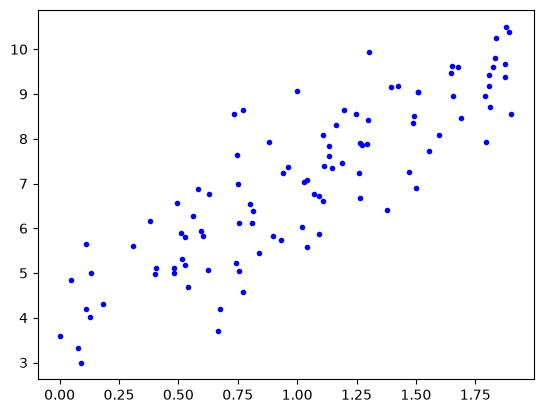

In [3]:
plt.plot(X, y, "b.")
plt.show()

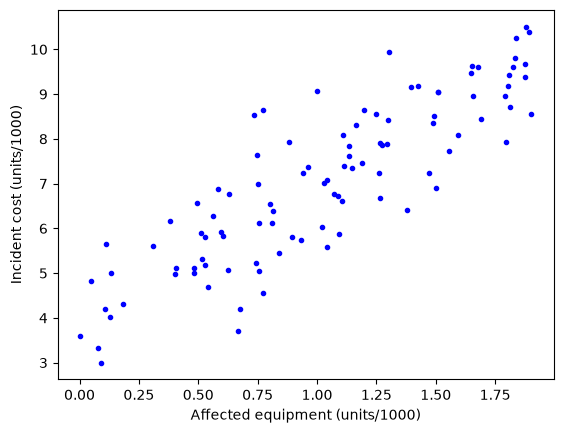

In [4]:
plt.plot(X, y, "b.")
plt.xlabel("Affected equipment (units/1000)")
plt.ylabel("Incident cost (units/1000)")
plt.show()

In [5]:
import pandas as pd

In [6]:
data = {"n_affected_equipment": X.flatten(), "cost": y.flatten()}
df = pd.DataFrame(data)
df.head(10)

,n_affected_equipment,cost
0,0.808474,6.127882
1,1.162098,8.314041
2,1.303366,9.945442
3,1.261648,7.240680
4,0.733185,8.543598
5,0.627308,6.772794
6,0.002719,3.603195
7,0.962750,7.372729
8,1.876329,9.663558
9,1.029395,7.023291


In [9]:
# Scaling the number of affected equipment
df["n_affected_equipment"] = df["n_affected_equipment"] * 10000
df["n_affected_equipment"] = df["n_affected_equipment"].astype(int) # Convert to integer

# Scaling the cost
df["cost"] = df["cost"] * 10000
df["cost"] = df["cost"].astype(int)
df.head(10)

,n_affected_equipment,cost
0,80840000,612780000
1,116200000,831400000
2,130330000,994540000
3,126160000,724060000
4,73310000,854350000
5,62730000,677270000
6,270000,360310000
7,96270000,737270000
8,187630000,966350000
9,102930000,702320000


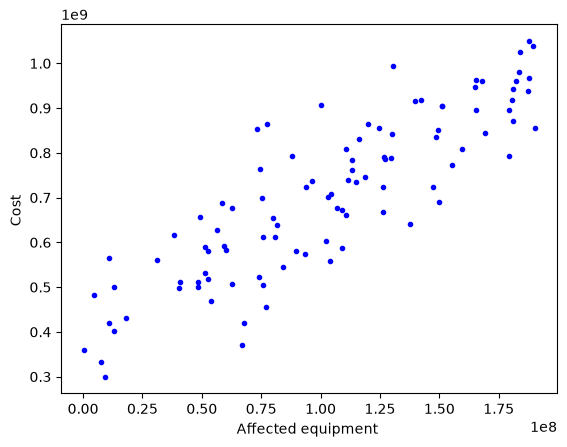

In [12]:
# Graph
plt.plot(df['n_affected_equipment'],df['cost'],"b.")
plt.xlabel("Affected equipment " )
plt.ylabel("Cost ")
plt.show()

In [14]:
# Model.
from sklearn.linear_model import LinearRegression

In [15]:
# Buildiong the model
lin_reg = LinearRegression()  
lin_reg.fit(df['n_affected_equipment'].values.reshape(-1,1), df['cost'].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.96]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.018e+08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.24e+08]


In [16]:
# Parameter Theta 0
lin_reg.intercept_

np.float64(401750632.64868206)

In [17]:
# Parameter Theta 1
lin_reg.coef_

array([2.9556168])

In [18]:
# Prediction
X_min_max = np.array([[df['n_affected_equipment'].min()], [df['n_affected_equipment'].max()]])
y_train_pred = lin_reg.predict(X_min_max)

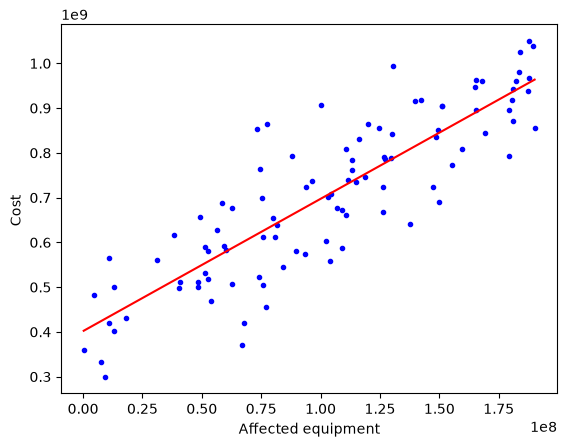

In [19]:
# Graph
plt.plot(df['n_affected_equipment'],df['cost'],"b.")
plt.plot(X_min_max, y_train_pred, "r-")
plt.xlabel("Affected equipment" )
plt.ylabel("Cost ")
plt.show()

In [20]:
# New Predictions
x_new = np.array([[1200]]) # 1200 Affected equipments

# Cost prediction
coste = lin_reg.predict(x_new)

print("The incident cost is: ", int(coste[0]), "$")

The incident cost is:  401754179 $


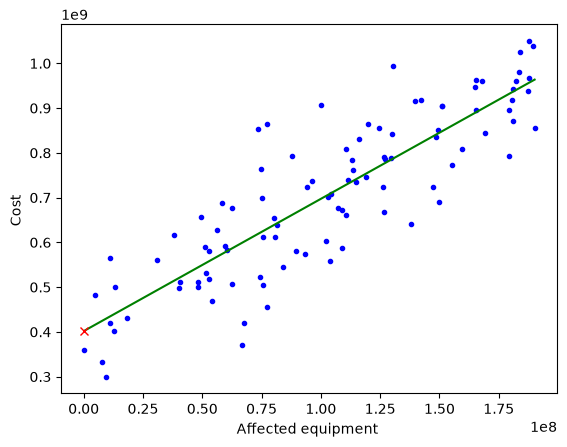

In [21]:
plt.plot(df['n_affected_equipment'],df['cost'],"b.")
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(x_new, coste, "rx")
plt.xlabel("Affected equipment " )
plt.ylabel("Cost ")
plt.show()